Importation of libraries

In [2]:
import pandas as pd

In [3]:
import matplotlib.pyplot as plt

In [4]:
df =pd.read_csv("steel_data.csv")

In [5]:
df.head(10)

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load
5,01/01/2018 01:30,3.28,3.56,0.0,0.0,67.76,100.0,5400,Weekday,Monday,Light_Load
6,01/01/2018 01:45,3.60,4.14,0.0,0.0,65.62,100.0,6300,Weekday,Monday,Light_Load
7,01/01/2018 02:00,3.60,4.28,0.0,0.0,64.37,100.0,7200,Weekday,Monday,Light_Load
8,01/01/2018 02:15,3.28,3.64,0.0,0.0,66.94,100.0,8100,Weekday,Monday,Light_Load
9,01/01/2018 02:30,3.78,4.72,0.0,0.0,62.51,100.0,9000,Weekday,Monday,Light_Load


Checking the data quality and testing the cells for missing values

In [6]:
print(df.dtypes)

date                                        str
Usage_kWh                               float64
Lagging_Current_Reactive.Power_kVarh    float64
Leading_Current_Reactive_Power_kVarh    float64
CO2(tCO2)                               float64
Lagging_Current_Power_Factor            float64
Leading_Current_Power_Factor            float64
NSM                                       int64
WeekStatus                                  str
Day_of_week                                 str
Load_Type                                   str
dtype: object


In [9]:
print('missing values:', df.isnull().sum().sum())

missing values: 0


In [10]:
df['date'] = pd.to_datetime(df['date'], format='%d/%m/%Y %H:%M')
df['hour'] = df['NSM'] // 3600

df[['date', 'NSM', 'hour']].head()

,date,NSM,hour
0,2018-01-01 00:15:00,900,0
1,2018-01-01 00:30:00,1800,0
2,2018-01-01 00:45:00,2700,0
3,2018-01-01 01:00:00,3600,1
4,2018-01-01 01:15:00,4500,1


In [15]:
df.columns = df.columns.str.lower()
df.groupby('load_type')['usage_kwh'].describe()

,count,mean,std,min,25%,50%,75%,max
load_type,,,,,,,,
Light_Load,18072.0,8.626207,17.906245,0.00,2.9500,3.310,4.03,140.29
Maximum_Load,7272.0,59.265314,29.749700,2.92,42.0025,56.630,75.31,151.67
Medium_Load,9696.0,38.445394,35.220166,2.52,4.4200,34.435,61.70,157.18


Deciding when the loads should change

In [17]:
df.groupby('load_type')['hour'].agg(['mean', 'median', 'min', 'max'])

,mean,median,min,max
load_type,,,,
Light_Load,7.509628,6.0,0,23
Maximum_Load,14.357261,14.0,10,23
Medium_Load,16.794554,18.0,9,23


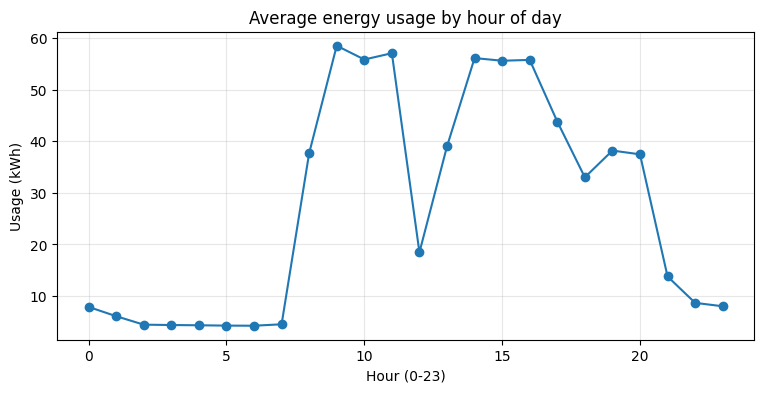

In [19]:
hourly_avg = df.groupby('hour')['usage_kwh'].mean()

plt.figure(figsize=(9, 4))
plt.plot(hourly_avg.index, hourly_avg.values, marker='o')
plt.title('Average energy usage by hour of day')
plt.xlabel('Hour (0-23)')
plt.ylabel('Usage (kWh)')
plt.grid(alpha=0.3)
plt.show()

<Figure size 700x400 with 0 Axes>

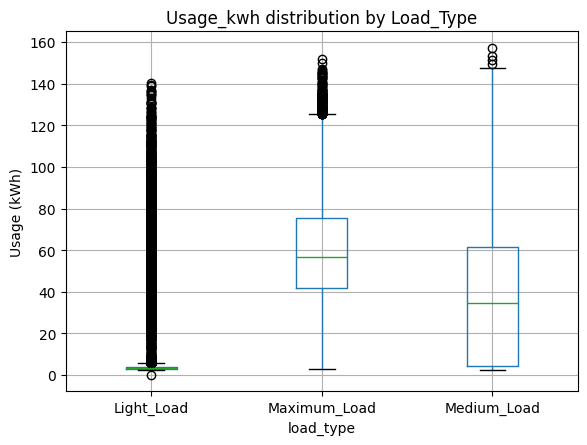

In [21]:
plt.figure(figsize=(7, 4))
df.boxplot(column='usage_kwh', by='load_type')
plt.title('Usage_kwh distribution by Load_Type')
plt.suptitle('')
plt.ylabel('Usage (kWh)')
plt.show()

checkins or updates

In [28]:
df.groupby('weekstatus')['usage_kwh'].mean ()

weekstatus
Weekday    33.624727
Weekend    11.732327
Name: usage_kwh, dtype: float64